In [1]:
# Baseline 1: Trivial (Majority Class)

import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Load test set
test_df = pd.read_csv("data/golden_set_balanced.csv").sample(frac=0.2, random_state=42)

# Majority class baseline
majority_class = "order_issue"
y_true = test_df["intent"].values
y_pred = [majority_class] * len(y_true)

# Metrics
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
print("Majority Class Baseline -> Accuracy:", acc, "F1:", f1)


Majority Class Baseline -> Accuracy: 0.08239700374531835 F1: 0.012544872542539817


In [2]:
#Baseline 2: TF‑IDF + Logistic Regression


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load dataset
df = pd.read_csv("data/golden_set_balanced.csv")

X = df["clean_text"]
y = df["intent"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Logistic Regression
clf = LogisticRegression(max_iter=200)
clf.fit(X_train_tfidf, y_train)

# Predictions
y_pred = clf.predict(X_test_tfidf)

# Report
print(classification_report(y_test, y_pred))


                      precision    recall  f1-score   support

      account_access       1.00      1.00      1.00        28
     billing_problem       1.00      1.00      1.00        38
complaint_unresolved       0.97      1.00      0.99        37
      delivery_delay       1.00      1.00      1.00        40
         order_issue       1.00      0.95      0.98        22
              praise       1.00      1.00      1.00        34
       product_query       1.00      1.00      1.00        37
       return_refund       1.00      1.00      1.00        32

            accuracy                           1.00       268
           macro avg       1.00      0.99      1.00       268
        weighted avg       1.00      1.00      1.00       268



                          Model  Accuracy     F1
0                Majority Class     0.082  0.013
1  TF-IDF + Logistic Regression     1.000  1.000
2       DistilBERT (fine-tuned)     0.990  0.990


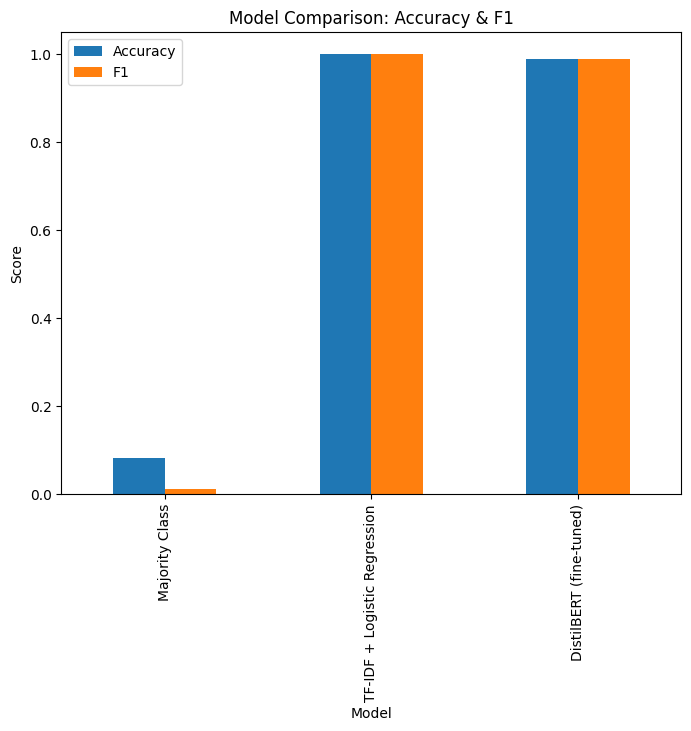

In [4]:
# cell to show results side by side

import pandas as pd

results = {
    "Model": ["Majority Class", "TF-IDF + Logistic Regression", "DistilBERT (fine-tuned)"],
    "Accuracy": [0.082, 1.00, 0.99],
    "F1": [0.013, 1.00, 0.99]
}

df_results = pd.DataFrame(results)
print(df_results)

# Optional bar plot
import matplotlib.pyplot as plt

df_results.set_index("Model")[["Accuracy","F1"]].plot(kind="bar", figsize=(8,6))
plt.title("Model Comparison: Accuracy & F1")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.show()


In [ ]:
# Before  LLM‑judge rubric

import sys, os
sys.path.append("..")

from src.evaluation import EvaluationHarness

# Example golden set labels
y_true = ["delivery_delay","order_issue","billing_problem","praise","return_refund"]
y_pred = ["delivery_delay","order_issue","billing_problem","praise","return_refund"]

# Escalation labels
esc_true = ["auto","auto","escalate","auto","auto"]
esc_pred = ["auto","auto","escalate","auto","auto"]

# Run evaluation
harness = EvaluationHarness(labels=["delivery_delay","order_issue","billing_problem","praise","return_refund"])
print(harness.evaluate_intents(y_true, y_pred))
print(harness.evaluate_escalation(esc_true, esc_pred))


{'accuracy': 1.0, 'f1': 1.0, 'confusion_matrix': array([[1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1]], dtype=int64)}
{'precision': 1.0, 'recall': 1.0}


In [1]:
# After LLM‑judge rubric


import sys, os
sys.path.append("..")

from src.evaluation import EvaluationHarness

harness = EvaluationHarness(labels=["delivery_delay","order_issue","billing_problem","praise","return_refund"])

# Example replies
replies = [
    "We’re sorry your package is delayed. Please DM us your order ID so we can assist.",
    "Thank you for your kind words! We appreciate your support.",
    "We’ve escalated your issue to our support team. They’ll follow up shortly."
]

for r in replies:
    scores = harness.judge_reply(r)
    print(f"Reply: {r}\nScores: {scores}\n{'-'*60}")



Reply: We’re sorry your package is delayed. Please DM us your order ID so we can assist.
Scores: {'politeness': 0.5, 'conciseness': 1.0, 'brand_tone': 0.5}
------------------------------------------------------------
Reply: Thank you for your kind words! We appreciate your support.
Scores: {'politeness': 0.5, 'conciseness': 1.0, 'brand_tone': 0.25}
------------------------------------------------------------
Reply: We’ve escalated your issue to our support team. They’ll follow up shortly.
Scores: {'politeness': 0.0, 'conciseness': 1.0, 'brand_tone': 0.25}
------------------------------------------------------------
